In [1]:
pip install pandas numpy scikit-learn matplotlib shap requests

--- Step 1: Ingesting Remote Source Data ---
Dataset Shape: (45211, 17)

Class Distribution (Imbalance Check):
y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

--- Step 2: Feature Engineering & Preprocessing ---

--- Step 3: Model Training ---
Training Logistic Regression...
Training Random Forest...

--- Step 4: Multi-Metric Evaluation ---

================ Logistic Regression Evaluation ================
Macro F1-Score: 0.3274
ROC-AUC Score:  0.8726

Detailed Performance Matrix:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.59      0.23      0.33      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.60      0.63      9043
weighted avg       0.87      0.89      0.87      9043


================ Random Forest Evaluation ================
Macro F1-Score: 0.5101
ROC-AUC Score:  0.9246

Detailed Performance Matrix:
              precision    recall

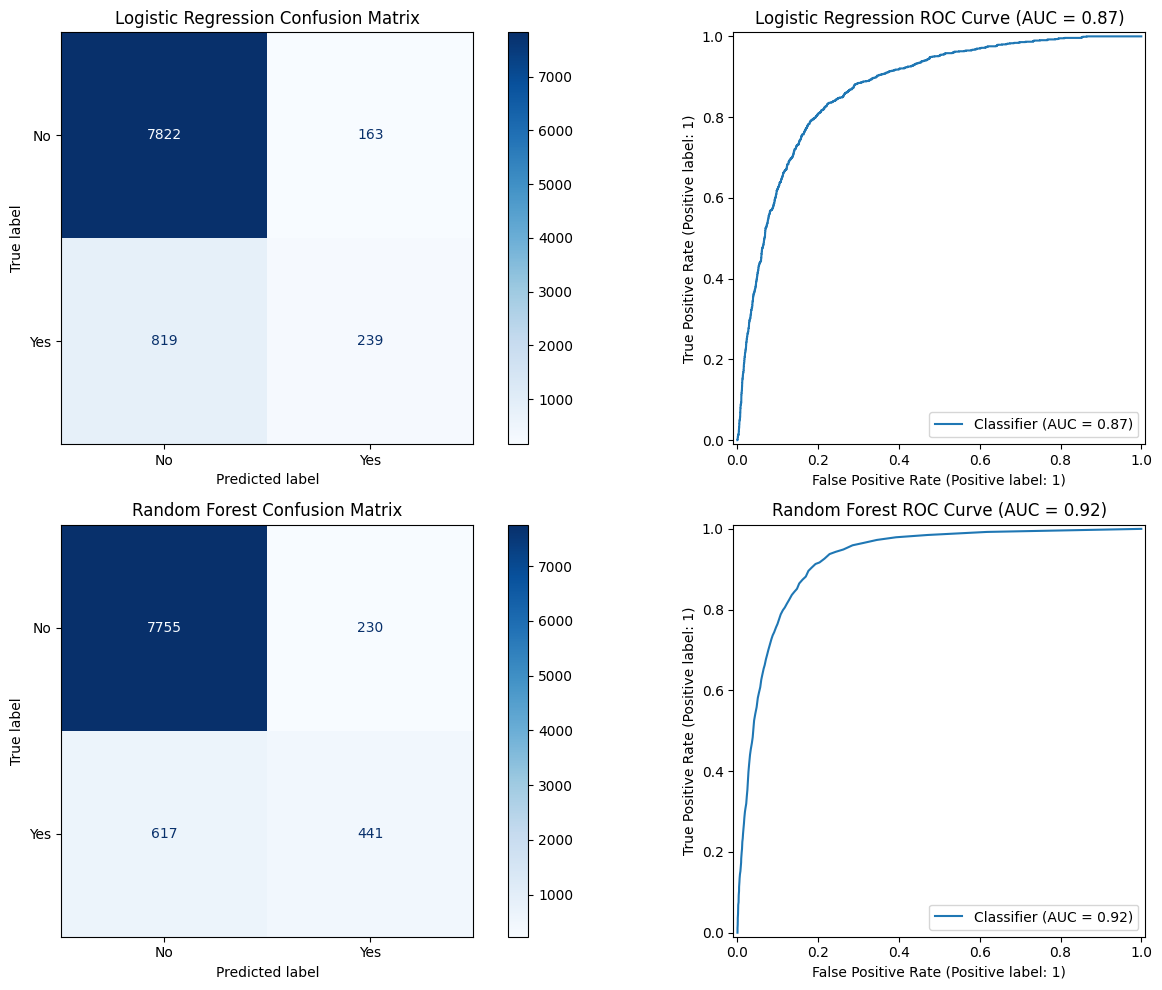


--- Step 5: Generating TreeSHAP Explanations ---

Rendering Global Feature Contribution Map...


/tmp/ipykernel_8424/483920543.py:162: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], sample_instances, show=False)


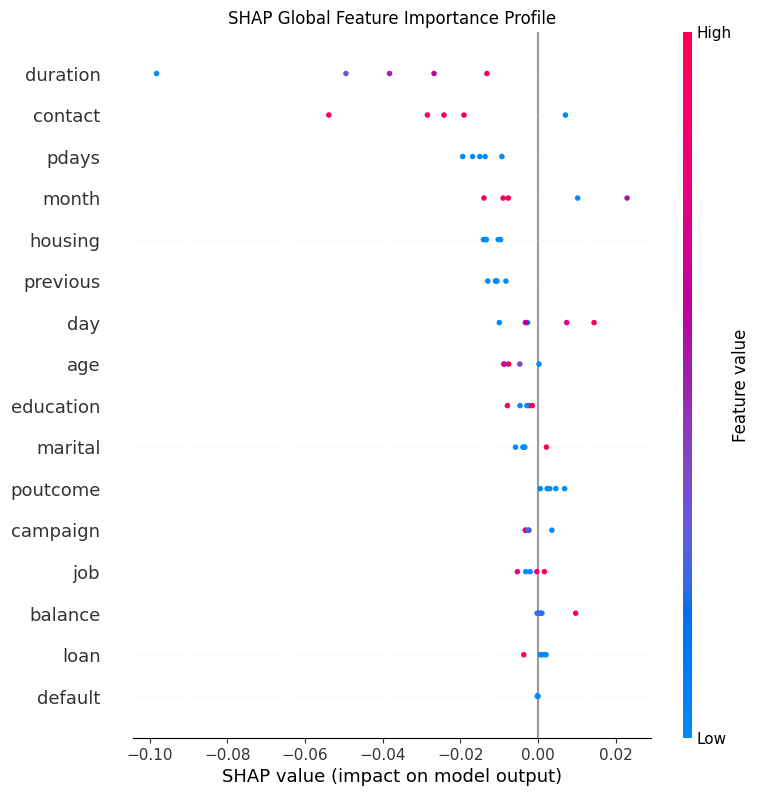


Deconstructing Local Feature Vectors (Individual Profiles):

--- Customer Transaction Record Index: 1392 ---
Ground Truth: No Subscription
Inference Probability: 0.00%


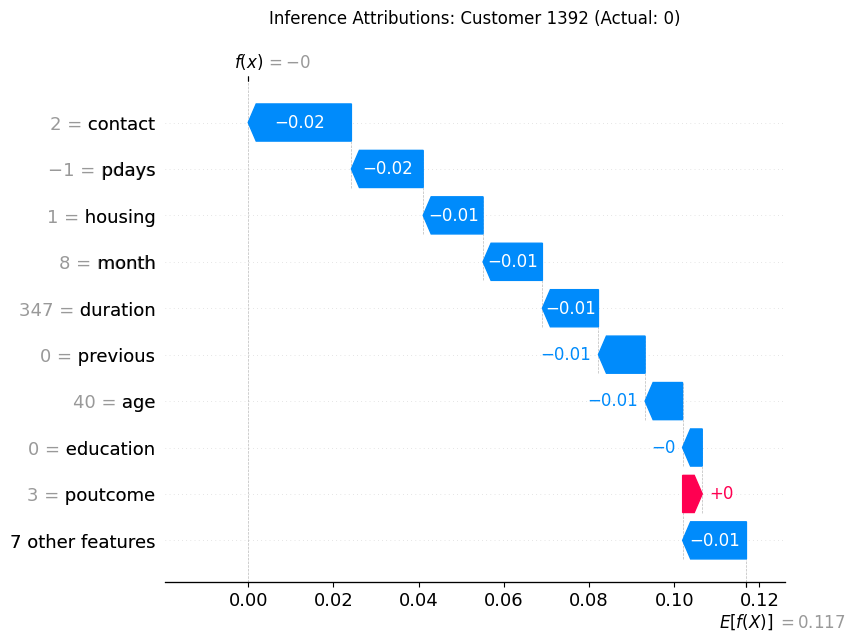


--- Customer Transaction Record Index: 7518 ---
Ground Truth: No Subscription
Inference Probability: 0.00%


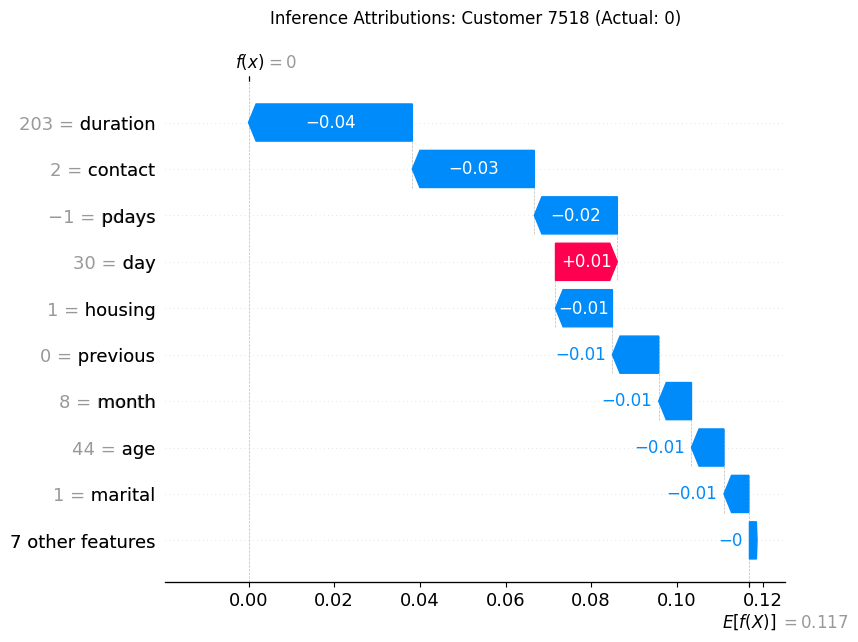


--- Customer Transaction Record Index: 12007 ---
Ground Truth: No Subscription
Inference Probability: 1.00%


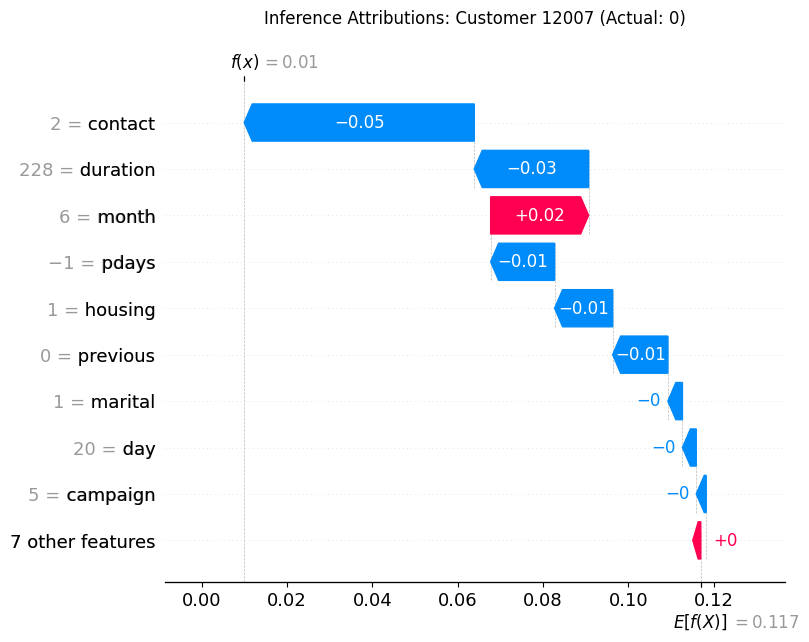


--- Customer Transaction Record Index: 5536 ---
Ground Truth: No Subscription
Inference Probability: 0.00%


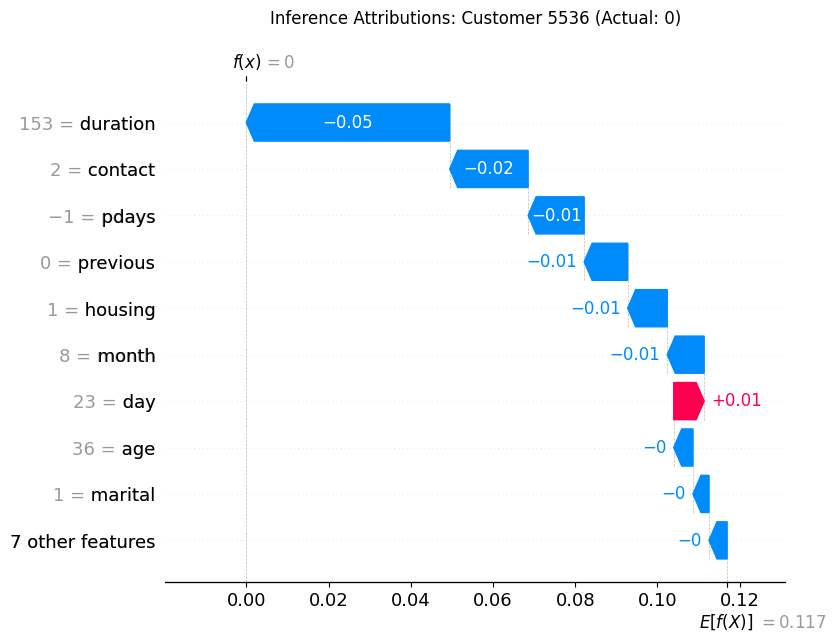


--- Customer Transaction Record Index: 29816 ---
Ground Truth: No Subscription
Inference Probability: 0.00%


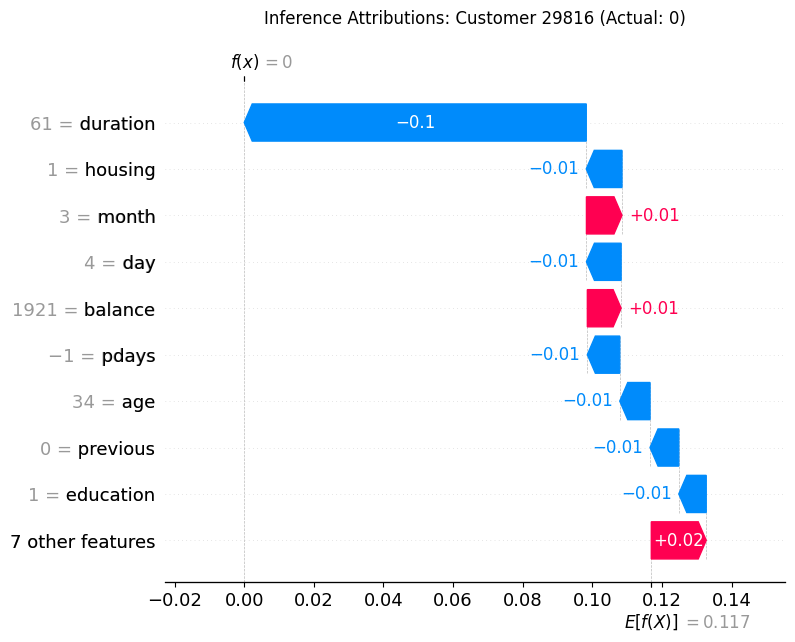

In [2]:
import io
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("--- Step 1: Ingesting Remote Source Data ---")

# Pulling directly from UCI ML Repository to ensure script self-containment
url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
response = requests.get(url)

# Memory-buffered extraction of the nested archive structure
with zipfile.ZipFile(io.BytesIO(response.content)) as outer_zip:
    with outer_zip.open("bank.zip") as inner_zip_file:
        with zipfile.ZipFile(io.BytesIO(inner_zip_file.read())) as inner_zip:
            # Utilizing 'bank-full.csv' (~45k records) for robust model training
            with inner_zip.open("bank-full.csv") as csv_file:
                df = pd.read_csv(csv_file, sep=";")

print(f"Dataset Shape: {df.shape}")
print("\nClass Distribution (Imbalance Check):")
print(df['y'].value_counts(normalize=True))


# =====================================================================
# 2. FEATURE ENGINEERING & PREPROCESSING PIPELINE
# =====================================================================
print("\n--- Step 2: Feature Engineering & Preprocessing ---")

X = df.drop(columns=['y'])
y = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

X_encoded = X.copy()
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Stratification is critical due to severe class imbalance (~11% positive rate)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Feature Scaling: Essential to prevent gradient distortion in Logistic Regression.
# Tree-based algorithms (Random Forest) will remain unaffected by this transformation.
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])


# =====================================================================
# 3. MODEL TRAINING & CALIBRATION
# =====================================================================
print("\n--- Step 3: Model Training ---")

# Baseline Linear Model: Calibrated with higher max_iter to guarantee convergence
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train_scaled, y_train)

# Ensemble Non-Linear Model: Leverages raw unscaled features for optimal partitioning
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train, y_train)


# =====================================================================
# 4. DISCRIMINATION & PERFORMANCE EVALUATION
# =====================================================================
print("\n--- Step 4: Multi-Metric Evaluation ---")

# Structuring evaluations to abstract model-specific matrix variations
execution_payload = {
    "Logistic Regression": (lr_model, X_test_scaled),
    "Random Forest": (rf_model, X_test)
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

plot_idx = 0
for name, (model, X_eval) in execution_payload.items():
    preds = model.predict(X_eval)
    probs = model.predict_proba(X_eval)[:, 1]

    # Primary Metrics: Prioritizing F1-Score over Accuracy due to class asymmetry
    f1 = f1_score(y_test, preds)
    roc_auc = roc_auc_score(y_test, probs)

    print(f"\n================ {name} Evaluation ================")
    print(f"Macro F1-Score: {f1:.4f}")
    print(f"ROC-AUC Score:  {roc_auc:.4f}")
    print("\nDetailed Performance Matrix:")
    print(classification_report(y_test, preds))

    # Confusion Matrix: Evaluates Raw True Negatives vs False Positives
    cm = confusion_matrix(y_test, preds)
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    cm_display.plot(ax=axes[plot_idx], cmap='Blues', values_format='d')
    axes[plot_idx].set_title(f'{name} Confusion Matrix')
    plot_idx += 1

    # ROC Curve: Evaluates Classifier Separation Threshold capabilities
    roc_display = RocCurveDisplay.from_predictions(y_test, probs, ax=axes[plot_idx])
    axes[plot_idx].set_title(f'{name} ROC Curve (AUC = {roc_auc:.2f})')
    plot_idx += 1

plt.tight_layout()
plt.show()


# =====================================================================
# 5. EXPLAINABLE AI (XAI) - MODEL INTERPRETABILITY
# =====================================================================
print("\n--- Step 5: Generating TreeSHAP Explanations ---")

# Initializing Explainer using TreeSHAP optimizations for exact local calculations
explainer = shap.TreeExplainer(rf_model)

# Sampling first 5 execution rows out of the test set for verification
sample_instances = X_test.head(5)
sample_actuals = y_test.head(5).values

# Extract conditional predictions. Index [:, :, 1] isolates the positive outcome ('yes')
shap_values = explainer(sample_instances)

print("\nRendering Global Feature Contribution Map...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[:, :, 1], sample_instances, show=False)
plt.title("SHAP Global Feature Importance Profile")
plt.show()

print("\nDeconstructing Local Feature Vectors (Individual Profiles):")
for i in range(5):
    customer_idx = sample_instances.index[i]
    actual_label = "Subscribed" if sample_actuals[i] == 1 else "No Subscription"
    pred_prob = rf_model.predict_proba(sample_instances.iloc[[i]])[0][1]

    print(f"\n--- Customer Transaction Record Index: {customer_idx} ---")
    print(f"Ground Truth: {actual_label}")
    print(f"Inference Probability: {pred_prob:.2%}")

    # Waterfall Plots map the positive/negative trajectories forcing the final inference value
    plt.figure(figsize=(12, 3))
    shap.plots.waterfall(shap_values[i, :, 1], max_display=10, show=False)
    plt.title(f"Inference Attributions: Customer {customer_idx} (Actual: {sample_actuals[i]})", pad=20)
    plt.show()